# AI Data Analyst Agent – Dataset Exploration

This notebook explores the Adult Income dataset and demonstrates
data analysis techniques used by the AI Data Analyst Agent.

Objectives:
• Understand dataset structure
• Perform exploratory data analysis
• Identify patterns and trends
• Generate insights

In [2]:
import sys
import os

#..   = go one folder up

sys.path.append(os.path.abspath(".."))
from src.agent import generate_insights
from src.data_loader import load_data
from src.eda_engine import basic_eda

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load Dataset

In [4]:
df = pd.read_csv("../data/adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


The dataset contains 32,561 rows and 15 columns representing demographic
information used to predict income levels.

# Missing Values Analysis

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Text(0.5, 1.0, 'Missing Data Heatmap')

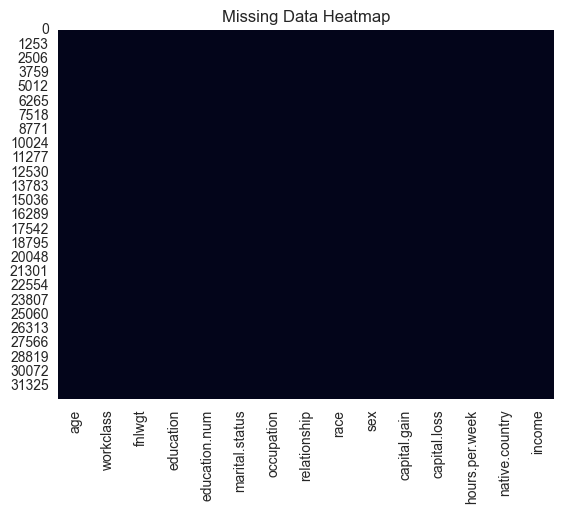

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")

# Statistical Summary

In [8]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Average age is around 38 years.
Most individuals work approximately 40 hours per week.
Capital gain values are heavily skewed.

# Distribution Analysis

Text(0, 0.5, 'Count')

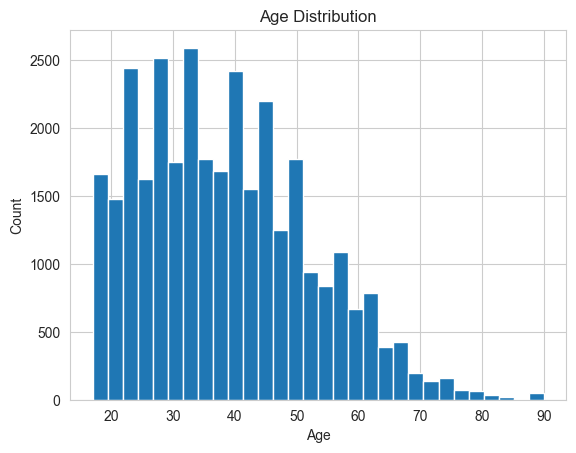

In [9]:
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

# Categorical Feature Analysis

Text(0.5, 1.0, 'Gender Distribution')

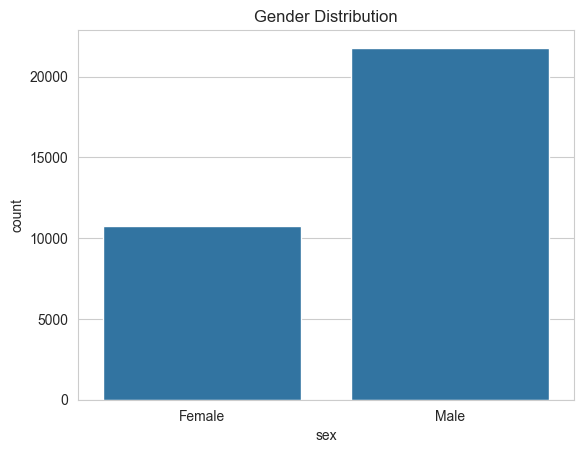

In [10]:
sns.countplot(data=df, x="sex")
plt.title("Gender Distribution")

Text(0.5, 1.0, 'Income Distribution')

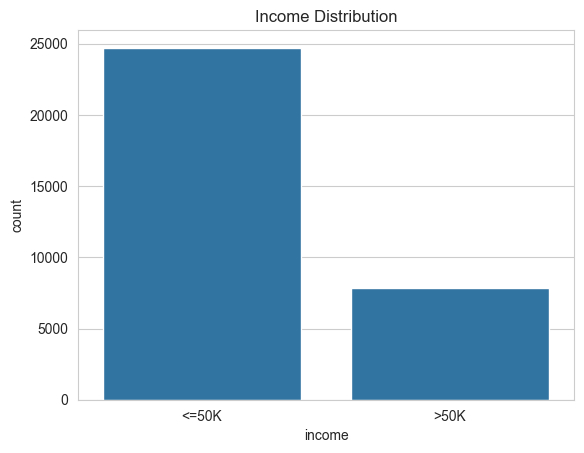

In [11]:
sns.countplot(data=df, x="income")
plt.title("Income Distribution")

# Correlation Analysis

Text(0.5, 1.0, 'Correlation Matrix')

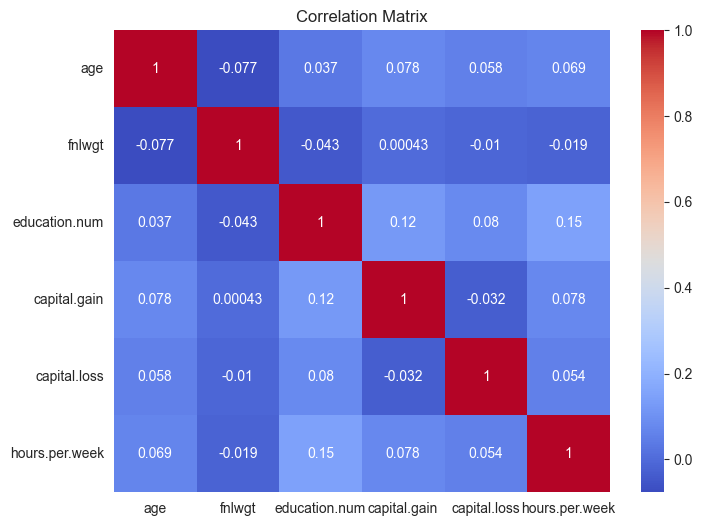

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

Education level has a positive relationship with income.
Age moderately correlates with hours worked.

# Numerical Feature Distribution
Most individuals fall between 30–45 years of age.

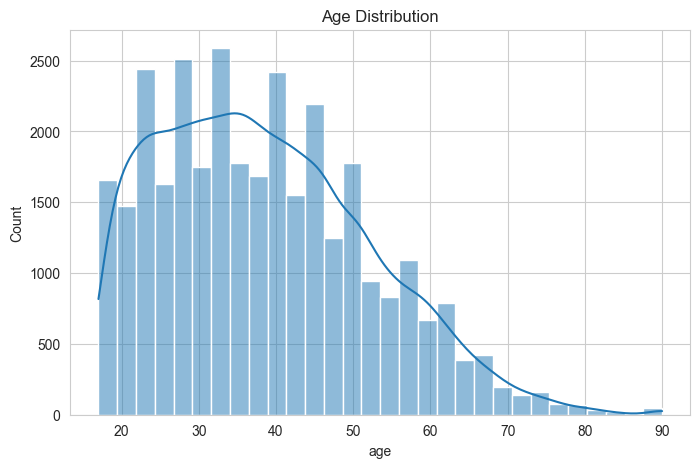

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

# Outlier Detection
Most individuals work around 40 hours per week, with some extreme outliers working more than 70 hours.

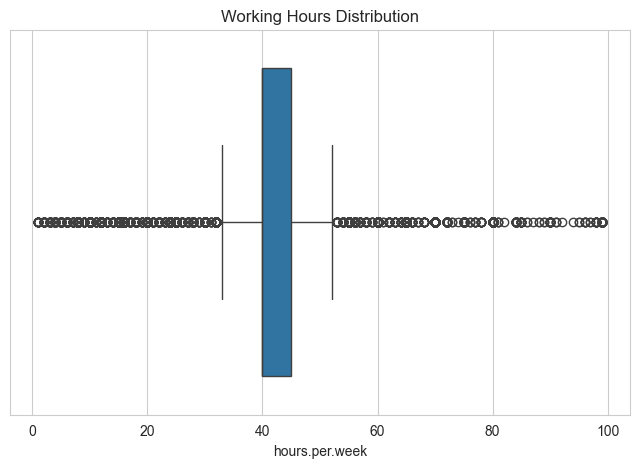

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["hours.per.week"])

plt.title("Working Hours Distribution")
plt.show()

# Category Comparison
Males appear more frequently in the >50K income category compared to females.

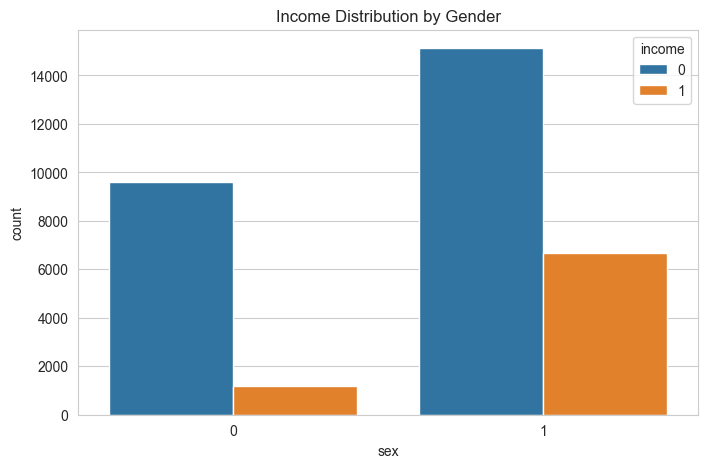

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="sex", hue="income", data=df)

plt.title("Income Distribution by Gender")
plt.show()

# Feature Relationships

Text(0.5, 1.0, 'Income vs Age')

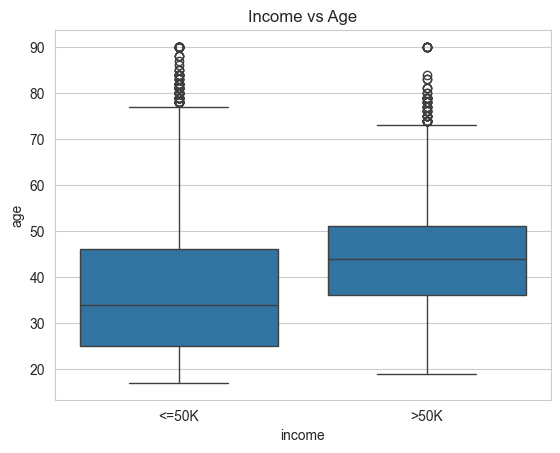

In [13]:
sns.boxplot(x="income", y="age", data=df)
plt.title("Income vs Age")

<Axes: xlabel='income', ylabel='hours.per.week'>

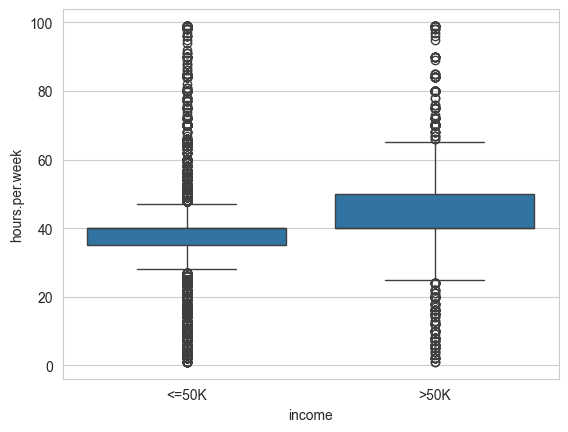

In [14]:
sns.boxplot(x="income", y="hours.per.week", data=df)

Higher income individuals tend to work slightly more hours per week.

# AI Insights Integration

In [15]:
from src.agent import generate_insights

summary = df.describe().to_string()

ai_insights = generate_insights(summary)

print(ai_insights)

OpenAI quota exceeded. Check billing.


# Key Finding Section

Key Findings:

1. Most individuals work approximately 40 hours per week.
2. Education level strongly influences income.
3. Capital gains show heavy skewness.
4. Age distribution is right skewed.

# Simple Machine Learning Model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode Categorical Variable

dataset has columns like : 
workclass
education
marital.status
occupation
race
sex
income

In [17]:
le = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = le.fit_transform(df[column])

Machine learning algorithms require numerical data, so categorical variables are encoded using Label Encoding.

# Define Features and Target

X → input features  
y → target variable (income)

In [18]:
X = df.drop("income", axis=1)
y = df["income"]

# Split Data Into Train/Test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

80% training
20% testing

# Train Model Here i use Random Forest
Random Forest is an ensemble algorithm that combines multiple decision trees.

In [20]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Make Predictions


In [21]:
y_pred = model.predict(X_test)

# Evaluate Model

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8538307999385844


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4976
           1       0.73      0.61      0.66      1537

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



# Confusion Matrix

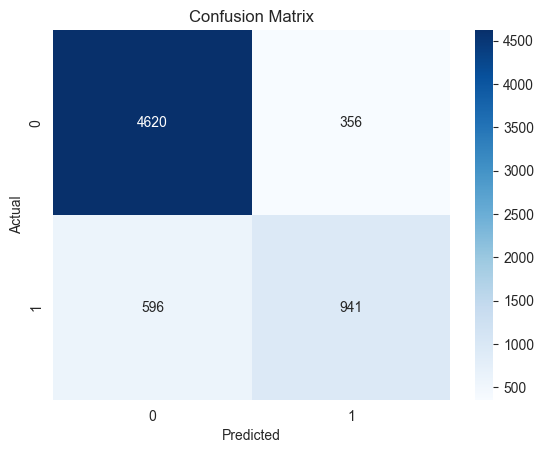

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance

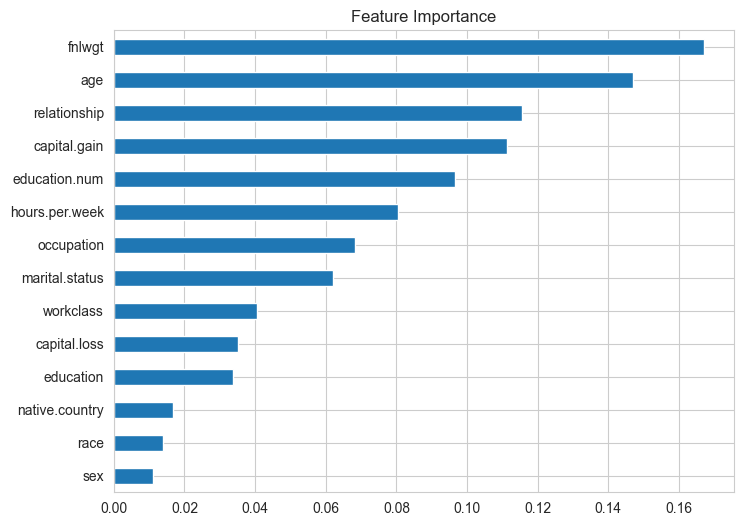

In [25]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance")
plt.show()

Education level and age appear to be strong predictors of income.

# Final Conclusion 
Model Performance Summary

The Random Forest classifier achieved an accuracy of ~85%.

Key factors influencing income include:
• Education level
• Age
• Hours worked per week

This demonstrates that demographic and employment features strongly influence income prediction.
